In [ ]:
!pip install kaggle

In [ ]:
USERNAME = "usename"
KEY = "api-key"

In [ ]:
!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = {"username": USERNAME,"key": KEY}

import json

with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c ml-11

  0% 0.00/55.6M [00:00<?, ?B/s]
100% 55.6M/55.6M [00:00<00:00, 917MB/s]


In [ ]:
!unzip ml-11.zip

Archive:  ml-11.zip
  inflating: sample_submission.csv   
  inflating: t1_webstat.csv          
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
webstat_df = pd.read_csv('t1_webstat.csv')

train_df['create_time'] = pd.to_datetime(train_df['create_time'])
test_df['create_time'] = pd.to_datetime(test_df['create_time'])
webstat_df['date_time'] = pd.to_datetime(webstat_df['date_time'])

##Анализ поведения пользователей на сайте


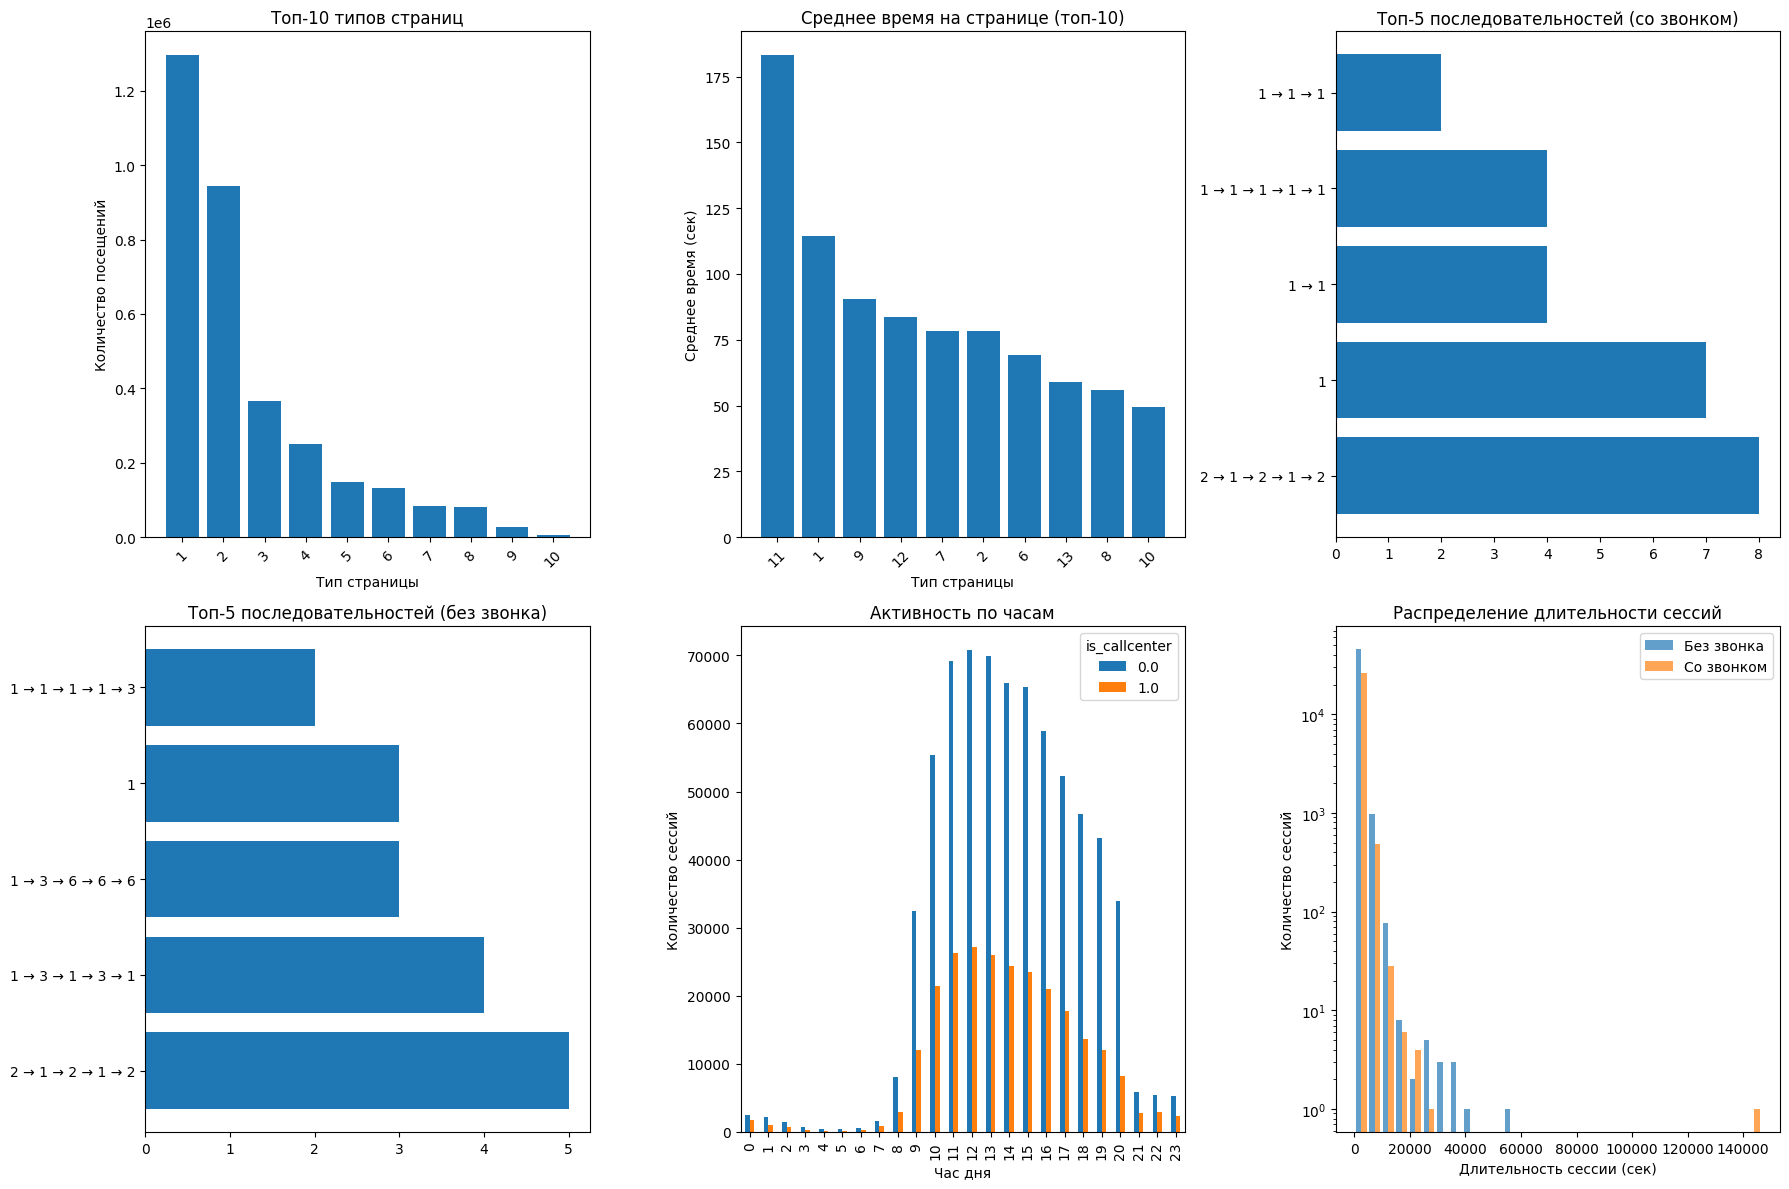

In [ ]:
def analyze_user_behavior(webstat_df, train_df):
    merged_df = pd.merge(webstat_df,
                        train_df[['sessionkey_id', 'is_callcenter']].drop_duplicates(),
                        on='sessionkey_id',
                        how='left')

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    page_type_counts = merged_df['page_type'].value_counts().head(10)
    axes[0, 0].bar(range(len(page_type_counts)), page_type_counts.values)
    axes[0, 0].set_title('Топ-10 типов страниц')
    axes[0, 0].set_xlabel('Тип страницы')
    axes[0, 0].set_ylabel('Количество посещений')
    axes[0, 0].set_xticks(range(len(page_type_counts)))
    axes[0, 0].set_xticklabels(page_type_counts.index, rotation=45)

    page_duration = merged_df.groupby('page_type')['pageview_duration_sec'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False).head(10)
    axes[0, 1].bar(range(len(page_duration)), page_duration['mean'])
    axes[0, 1].set_title('Среднее время на странице (топ-10)')
    axes[0, 1].set_xlabel('Тип страницы')
    axes[0, 1].set_ylabel('Среднее время (сек)')
    axes[0, 1].set_xticks(range(len(page_duration)))
    axes[0, 1].set_xticklabels(page_duration.index, rotation=45)

    def get_page_sequences(df, session_ids):
        sequences = []
        for session in session_ids:
            session_pages = df[df['sessionkey_id'] == session].sort_values('pageview_number')['page_type'].tolist()
            sequences.append(' → '.join(map(str, session_pages[:5])))  # Берем первые 5 страниц
        return pd.Series(sequences).value_counts().head(5)

    call_sessions = merged_df[merged_df['is_callcenter'] == 1]['sessionkey_id'].unique()
    no_call_sessions = merged_df[merged_df['is_callcenter'] == 0]['sessionkey_id'].unique()

    call_sequences = get_page_sequences(merged_df, call_sessions[:100])  # Ограничим для скорости
    no_call_sequences = get_page_sequences(merged_df, no_call_sessions[:100])

    axes[0, 2].barh(range(len(call_sequences)), call_sequences.values)
    axes[0, 2].set_title('Топ-5 последовательностей (со звонком)')
    axes[0, 2].set_yticks(range(len(call_sequences)))
    axes[0, 2].set_yticklabels(call_sequences.index)

    axes[1, 0].barh(range(len(no_call_sequences)), no_call_sequences.values)
    axes[1, 0].set_title('Топ-5 последовательностей (без звонка)')
    axes[1, 0].set_yticks(range(len(no_call_sequences)))
    axes[1, 0].set_yticklabels(no_call_sequences.index)

    merged_df['hour'] = merged_df['date_time'].dt.hour
    hour_dist = merged_df.groupby(['hour', 'is_callcenter']).size().unstack(fill_value=0)
    hour_dist.plot(kind='bar', ax=axes[1, 1])
    axes[1, 1].set_title('Активность по часам')
    axes[1, 1].set_xlabel('Час дня')
    axes[1, 1].set_ylabel('Количество сессий')

    session_duration = merged_df.groupby('sessionkey_id').agg({
        'pageview_duration_sec': 'sum',
        'is_callcenter': 'first'
    }).reset_index()

    axes[1, 2].hist([session_duration[session_duration['is_callcenter'] == 0]['pageview_duration_sec'].abs(),
                    session_duration[session_duration['is_callcenter'] == 1]['pageview_duration_sec'].abs()],
                   bins=30, alpha=0.7, label=['Без звонка', 'Со звонком'])
    axes[1, 2].set_title('Распределение длительности сессий')
    axes[1, 2].set_xlabel('Длительность сессии (сек)')
    axes[1, 2].set_ylabel('Количество сессий')
    axes[1, 2].legend()
    axes[1, 2].set_yscale('log')

    plt.tight_layout()
    plt.show()

    return merged_df, session_duration

merged_data, session_stats = analyze_user_behavior(webstat_df, train_df)

как мы видим, первая страниц наиболе популярна, особенно среди случае со звоноком. думаю, это значит, что стоит учитывать тип страницы. время суток тоже немного роляет, можно заметить, что около середины дня люди в ~60-70% случаев не звонят (ну вроде видно из графика), а вот ближе к вечеру (от 20.00 до часа ночи, скажем) конверсия стремиться ближе к 50-60%. причем, в 20.00 люди вообще не хотят звонить, но, видимо, они просто приходят уставшие с работы, ужинают и у них жизнь после вкусной еды налаживается и она сразу же хотят позвонить кому-нибудь)))

то же самое и утром, они просыпаются, едут на работу и просто листают вещи, но у них нет возможности из метро позвонить, а вот когда они уже дома, они могут и позвонить. короче говоря, в рабочее время люди обычно не звонят, вот что следует из графика (важно сказать, что я обащаю внимание не на общее число звонокв, на соотоношение случаев со звонками к случаям без звоноков)

##Анализ признаков заказов


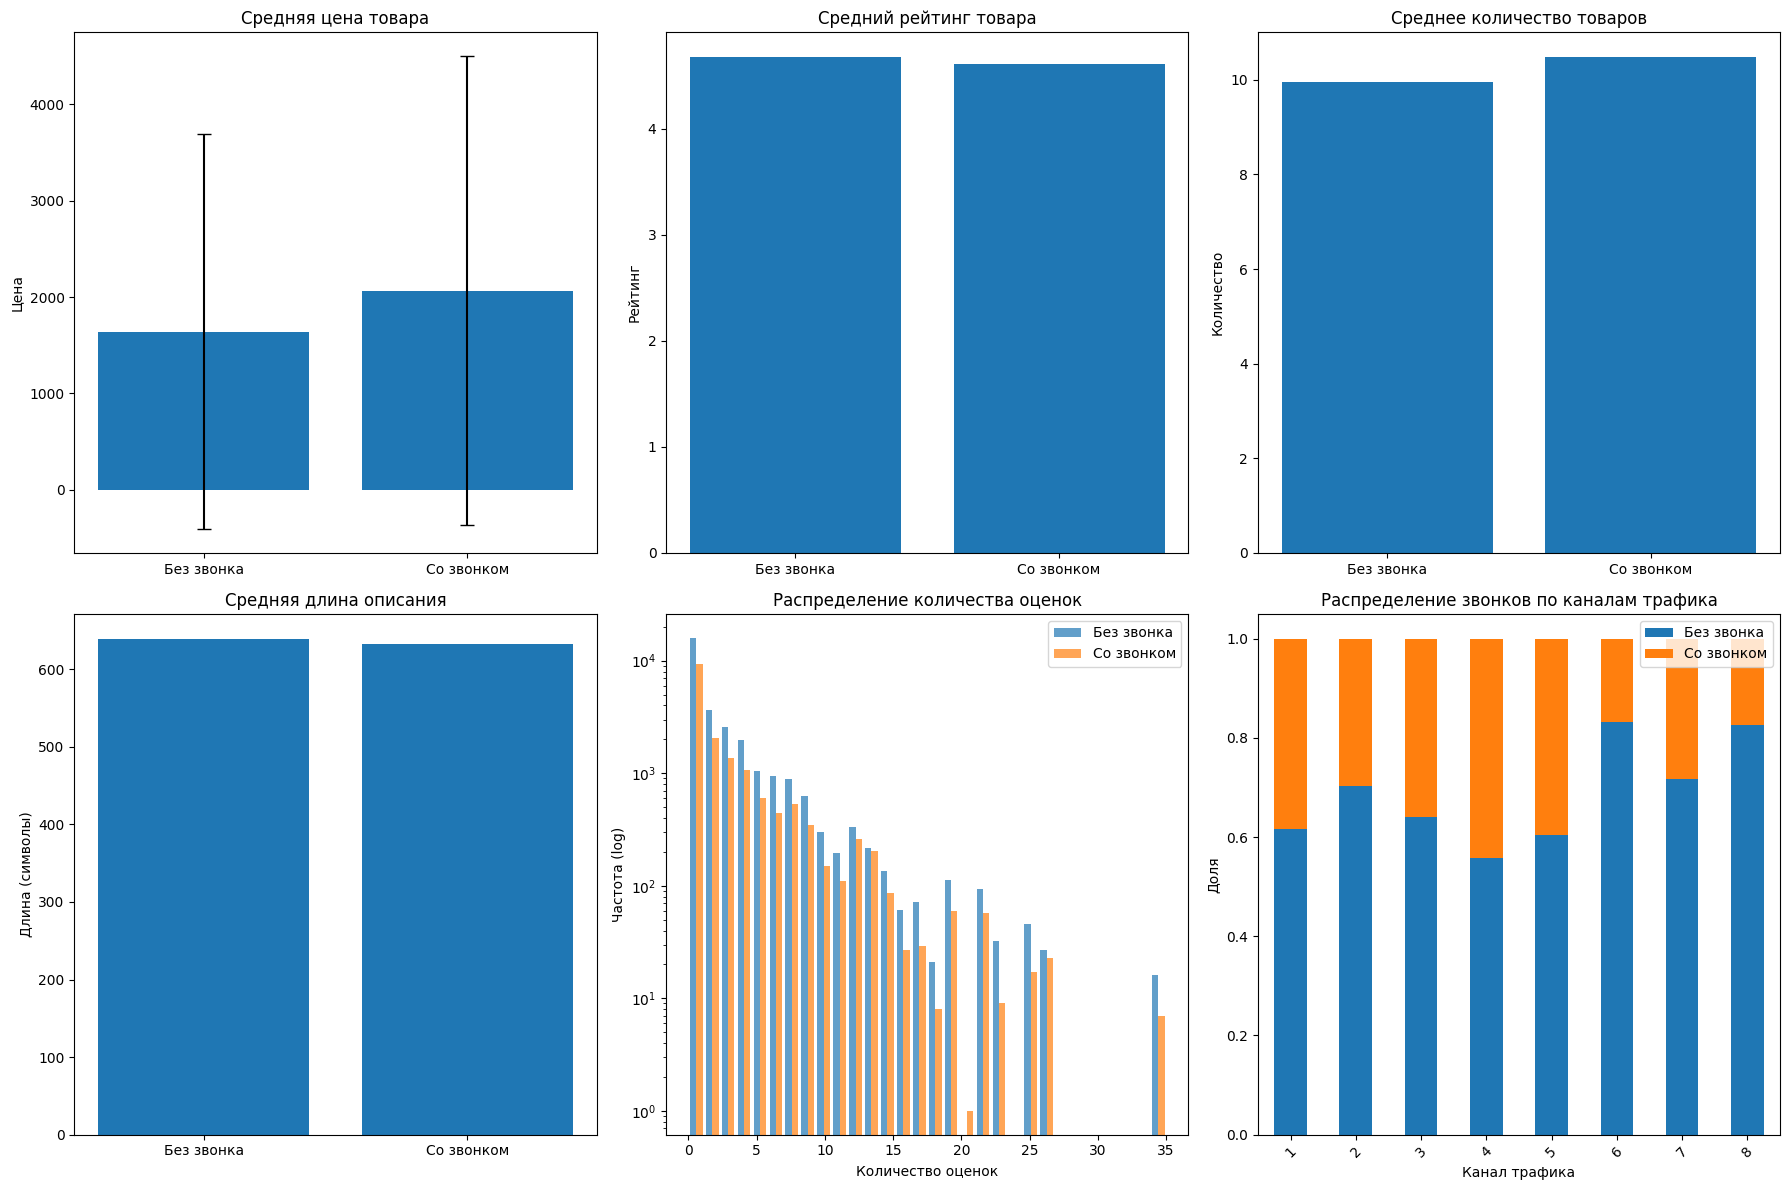

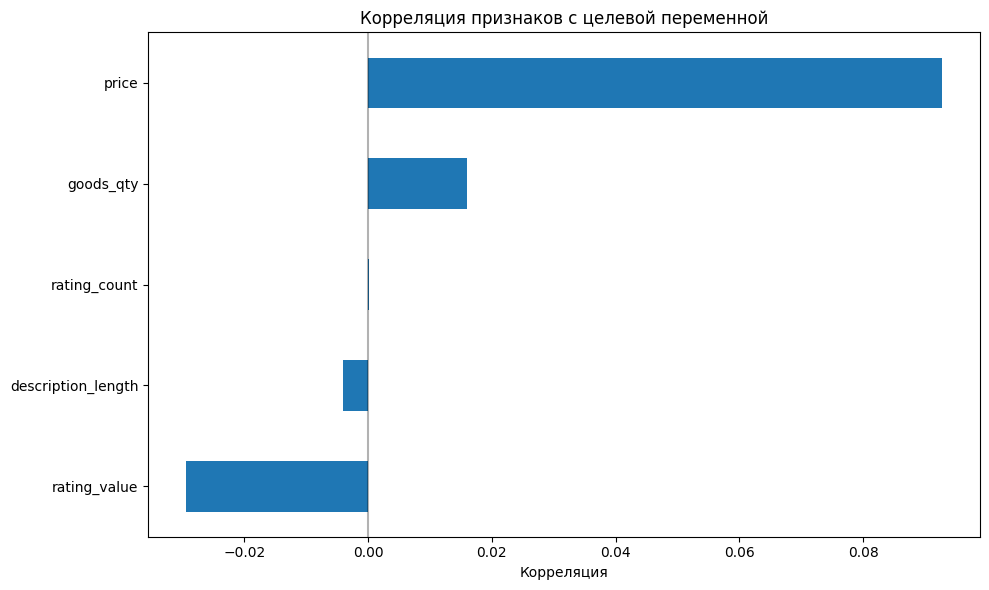

In [ ]:
def analyze_order_features(train_df):
    """Анализ признаков связанных с заказами"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    price_stats = train_df.groupby('is_callcenter')['price'].agg(['mean', 'median', 'std'])

    axes[0, 0].bar(['Без звонка', 'Со звонком'], price_stats['mean'])
    axes[0, 0].errorbar(['Без звонка', 'Со звонком'], price_stats['mean'],
                       yerr=price_stats['std'], fmt='none', color='black', capsize=5)
    axes[0, 0].set_title('Средняя цена товара')
    axes[0, 0].set_ylabel('Цена')

    rating_stats = train_df.groupby('is_callcenter')['rating_value'].agg(['mean', 'median'])
    axes[0, 1].bar(['Без звонка', 'Со звонком'], rating_stats['mean'])
    axes[0, 1].set_title('Средний рейтинг товара')
    axes[0, 1].set_ylabel('Рейтинг')

    qty_stats = train_df.groupby('is_callcenter')['goods_qty'].agg(['mean', 'median'])
    axes[0, 2].bar(['Без звонка', 'Со звонком'], qty_stats['mean'])
    axes[0, 2].set_title('Среднее количество товаров')
    axes[0, 2].set_ylabel('Количество')

    desc_stats = train_df.groupby('is_callcenter')['description_length'].agg(['mean', 'median'])
    axes[1, 0].bar(['Без звонка', 'Со звонком'], desc_stats['mean'])
    axes[1, 0].set_title('Средняя длина описания')
    axes[1, 0].set_ylabel('Длина (символы)')

    axes[1, 1].hist([train_df[train_df['is_callcenter'] == 0]['rating_count'],
                    train_df[train_df['is_callcenter'] == 1]['rating_count']],
                   bins=30, alpha=0.7, label=['Без звонка', 'Со звонком'], log=True)
    axes[1, 1].set_title('Распределение количества оценок')
    axes[1, 1].set_xlabel('Количество оценок')
    axes[1, 1].set_ylabel('Частота (log)')
    axes[1, 1].legend()

    medium_dist = train_df.groupby(['utm_medium', 'is_callcenter']).size().unstack(fill_value=0)
    medium_dist_norm = medium_dist.div(medium_dist.sum(axis=1), axis=0)
    medium_dist_norm.plot(kind='bar', stacked=True, ax=axes[1, 2])
    axes[1, 2].set_title('Распределение звонков по каналам трафика')
    axes[1, 2].set_xlabel('Канал трафика')
    axes[1, 2].set_ylabel('Доля')
    axes[1, 2].legend(['Без звонка', 'Со звонком'])
    axes[1, 2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    numeric_cols = ['price', 'rating_value', 'rating_count', 'description_length', 'goods_qty']
    correlations = train_df[numeric_cols + ['is_callcenter']].corr()['is_callcenter'].drop('is_callcenter')

    fig, ax = plt.subplots(figsize=(10, 6))
    correlations.sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Корреляция признаков с целевой переменной')
    ax.set_xlabel('Корреляция')
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)

    plt.tight_layout()
    plt.show()

analyze_order_features(train_df)

как видим, большинство признаков заказов почти ни на что не влияют, так как и для случаев со звонком, и для случае без звонка, данные примерно одинаковые (поэтому я почти не включил их в фичи)

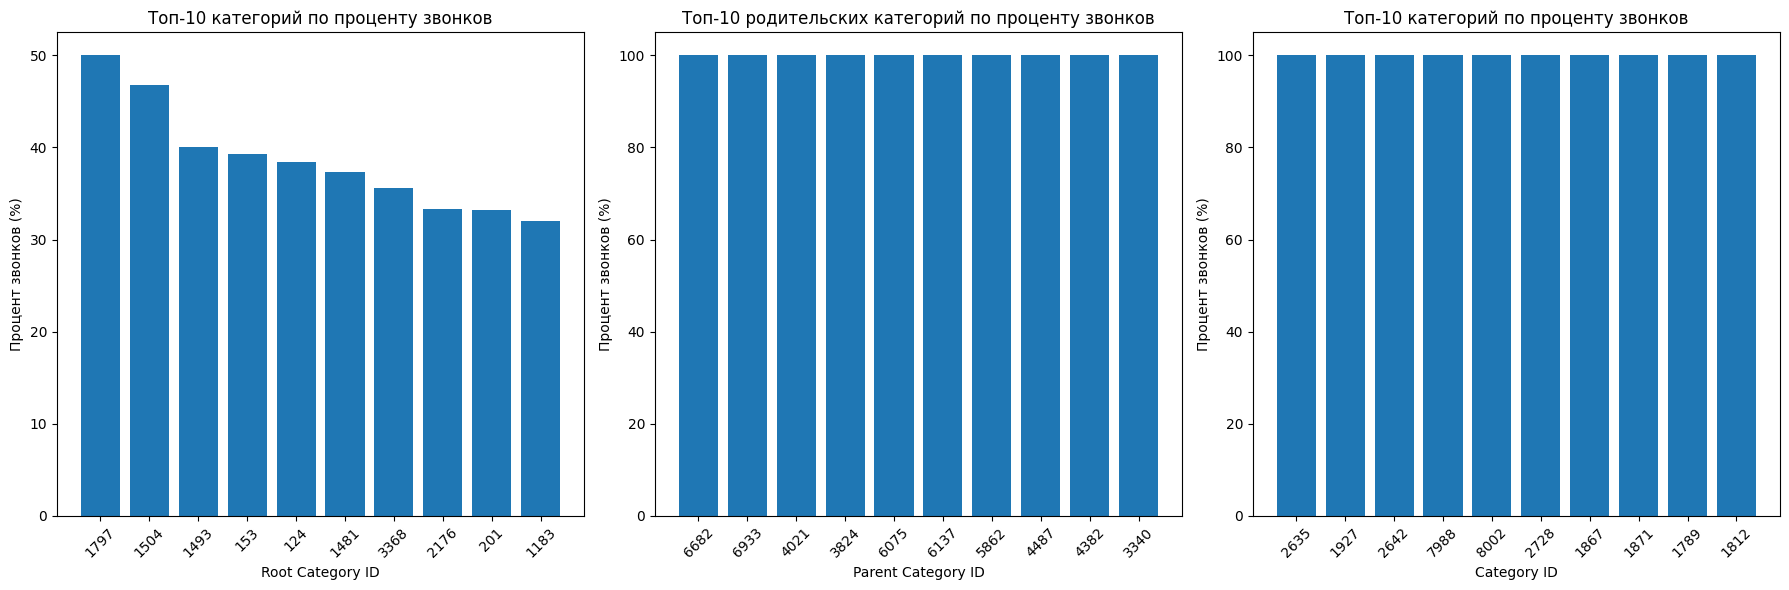

In [ ]:
def analyze_categories(train_df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    call_rate_by_root = train_df.groupby('root_id')['is_callcenter'].mean().sort_values(ascending=False).head(10)
    axes[0].bar(range(len(call_rate_by_root)), call_rate_by_root.values * 100)
    axes[0].set_title('Топ-10 категорий по проценту звонков')
    axes[0].set_xlabel('Root Category ID')
    axes[0].set_ylabel('Процент звонков (%)')
    axes[0].set_xticks(range(len(call_rate_by_root)))
    axes[0].set_xticklabels(call_rate_by_root.index, rotation=45)

    call_rate_by_parent = train_df.groupby('parent_id')['is_callcenter'].mean().sort_values(ascending=False).head(10)
    axes[1].bar(range(len(call_rate_by_parent)), call_rate_by_parent.values * 100)
    axes[1].set_title('Топ-10 родительских категорий по проценту звонков')
    axes[1].set_xlabel('Parent Category ID')
    axes[1].set_ylabel('Процент звонков (%)')
    axes[1].set_xticks(range(len(call_rate_by_parent)))
    axes[1].set_xticklabels(call_rate_by_parent.index, rotation=45)

    call_rate_by_category = train_df.groupby('category_id')['is_callcenter'].mean().sort_values(ascending=False).head(10)
    axes[2].bar(range(len(call_rate_by_category)), call_rate_by_category.values * 100)
    axes[2].set_title('Топ-10 категорий по проценту звонков')
    axes[2].set_xlabel('Category ID')
    axes[2].set_ylabel('Процент звонков (%)')
    axes[2].set_xticks(range(len(call_rate_by_category)))
    axes[2].set_xticklabels(call_rate_by_category.index, rotation=45)

    plt.tight_layout()
    plt.show()

    return call_rate_by_root, call_rate_by_parent, call_rate_by_category

root_stats, parent_stats, category_stats = analyze_categories(train_df)

такое ощущение, что категория почти не роляет... самые бесполезные 35 строк кода в моей жизни...

In [ ]:
def create_session_features(webstat_df):
    session_features = webstat_df.groupby('sessionkey_id').agg({
        'page_type': ['count', lambda x: x.nunique()],
        'pageview_duration_sec': ['sum', 'mean', 'std', 'max', 'min'],
        'pageview_number': 'max',
        'date_time': ['min', 'max']
    })

    session_features.columns = [
        'total_pages', 'unique_pages',
        'total_duration', 'mean_duration', 'std_duration', 'max_duration', 'min_duration',
        'max_page_number',
        'session_start', 'session_end'
    ]

    session_features['session_duration'] = (session_features['session_end'] -
                                           session_features['session_start']).dt.total_seconds()

    session_features['pages_per_minute'] = session_features['total_pages'] / (session_features['session_duration'] / 60 + 1)

    session_features = session_features.drop(['session_start', 'session_end'], axis=1)

    def get_session_sequence(row):
        session_id = row.name
        pages = webstat_df[webstat_df['sessionkey_id'] == session_id].sort_values('pageview_number')['page_type'].tolist()

        features = {}

        features['starts_with_main'] = 1 if pages and pages[0] == 'main' else 0
        features['ends_with_checkout'] = 1 if pages and pages[-1] in ['cart', 'checkout', 'order'] else 0
        features['back_navigation_count'] = sum(1 for i in range(1, len(pages)) if pages[i] == pages[i-1])
        features['has_faq_page'] = 1 if any('faq' in str(p).lower() or 'help' in str(p).lower() for p in pages) else 0
        features['has_contacts_page'] = 1 if any('contact' in str(p).lower() for p in pages) else 0

        return pd.Series(features)

    if len(session_features) > 10000:
        sequence_features = session_features.sample(10000, random_state=42).apply(get_session_sequence, axis=1)
    else:
        sequence_features = session_features.apply(get_session_sequence, axis=1)

    session_features = pd.concat([session_features, sequence_features], axis=1)

    return session_features

session_features = create_session_features(webstat_df)

=== Оценка линейной модели ===
ROC-AUC: 0.7568

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.66      0.75       104
           1       0.50      0.78      0.61        45

    accuracy                           0.70       149
   macro avg       0.69      0.72      0.68       149
weighted avg       0.76      0.70      0.71       149



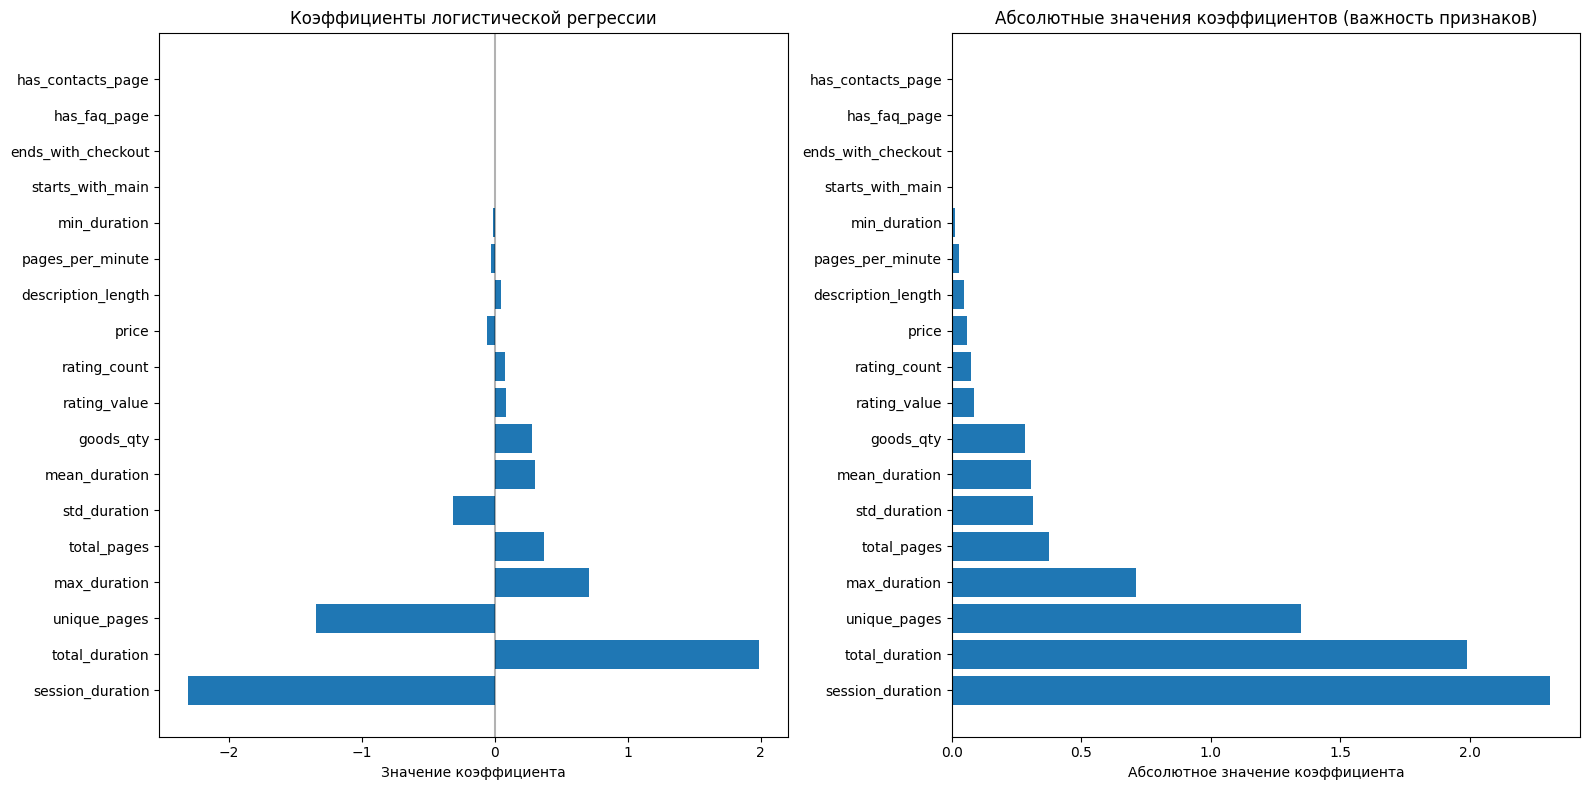

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

def analyze_with_linear_model(train_df, session_features):
    train_with_session = pd.merge(train_df, session_features,
                                 on='sessionkey_id', how='left')

    all_features = [
        'price', 'rating_value', 'rating_count',
        'description_length', 'goods_qty',
        'total_pages', 'unique_pages', 'total_duration',
        'mean_duration', 'std_duration', 'max_duration',
        'min_duration', 'session_duration', 'pages_per_minute'
    ]

    data_for_model = train_with_session[all_features + ['is_callcenter', 'sessionkey_id']].dropna()

    X = data_for_model[all_features]
    y = data_for_model['is_callcenter']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)

    print("=== Оценка линейной модели ===")
    print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))

    feature_importance = pd.DataFrame({
        'feature': all_features,
        'coefficient': model.coef_[0],
        'abs_coefficient': np.abs(model.coef_[0])
    }).sort_values('abs_coefficient', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].barh(range(len(feature_importance)), feature_importance['coefficient'].values)
    axes[0].set_yticks(range(len(feature_importance)))
    axes[0].set_yticklabels(feature_importance['feature'])
    axes[0].set_title('Коэффициенты логистической регрессии')
    axes[0].set_xlabel('Значение коэффициента')
    axes[0].axvline(x=0, color='black', linestyle='-', alpha=0.3)

    axes[1].barh(range(len(feature_importance)), feature_importance['abs_coefficient'].values)
    axes[1].set_yticks(range(len(feature_importance)))
    axes[1].set_yticklabels(feature_importance['feature'])
    axes[1].set_title('Абсолютные значения коэффициентов (важность признаков)')
    axes[1].set_xlabel('Абсолютное значение коэффициента')

    plt.tight_layout()
    plt.show()

    return model, feature_importance, data_for_model

model, feature_importance, model_data = analyze_with_linear_model(train_df, session_features)

касательно времени- как я и говорил, в районе позднего вечера все вдруг решают сделать фул закуп)

насчет категорий- хрень какая-то, вероятно, 50% это просто один из двух товаров купили, вот и вышел большой процент

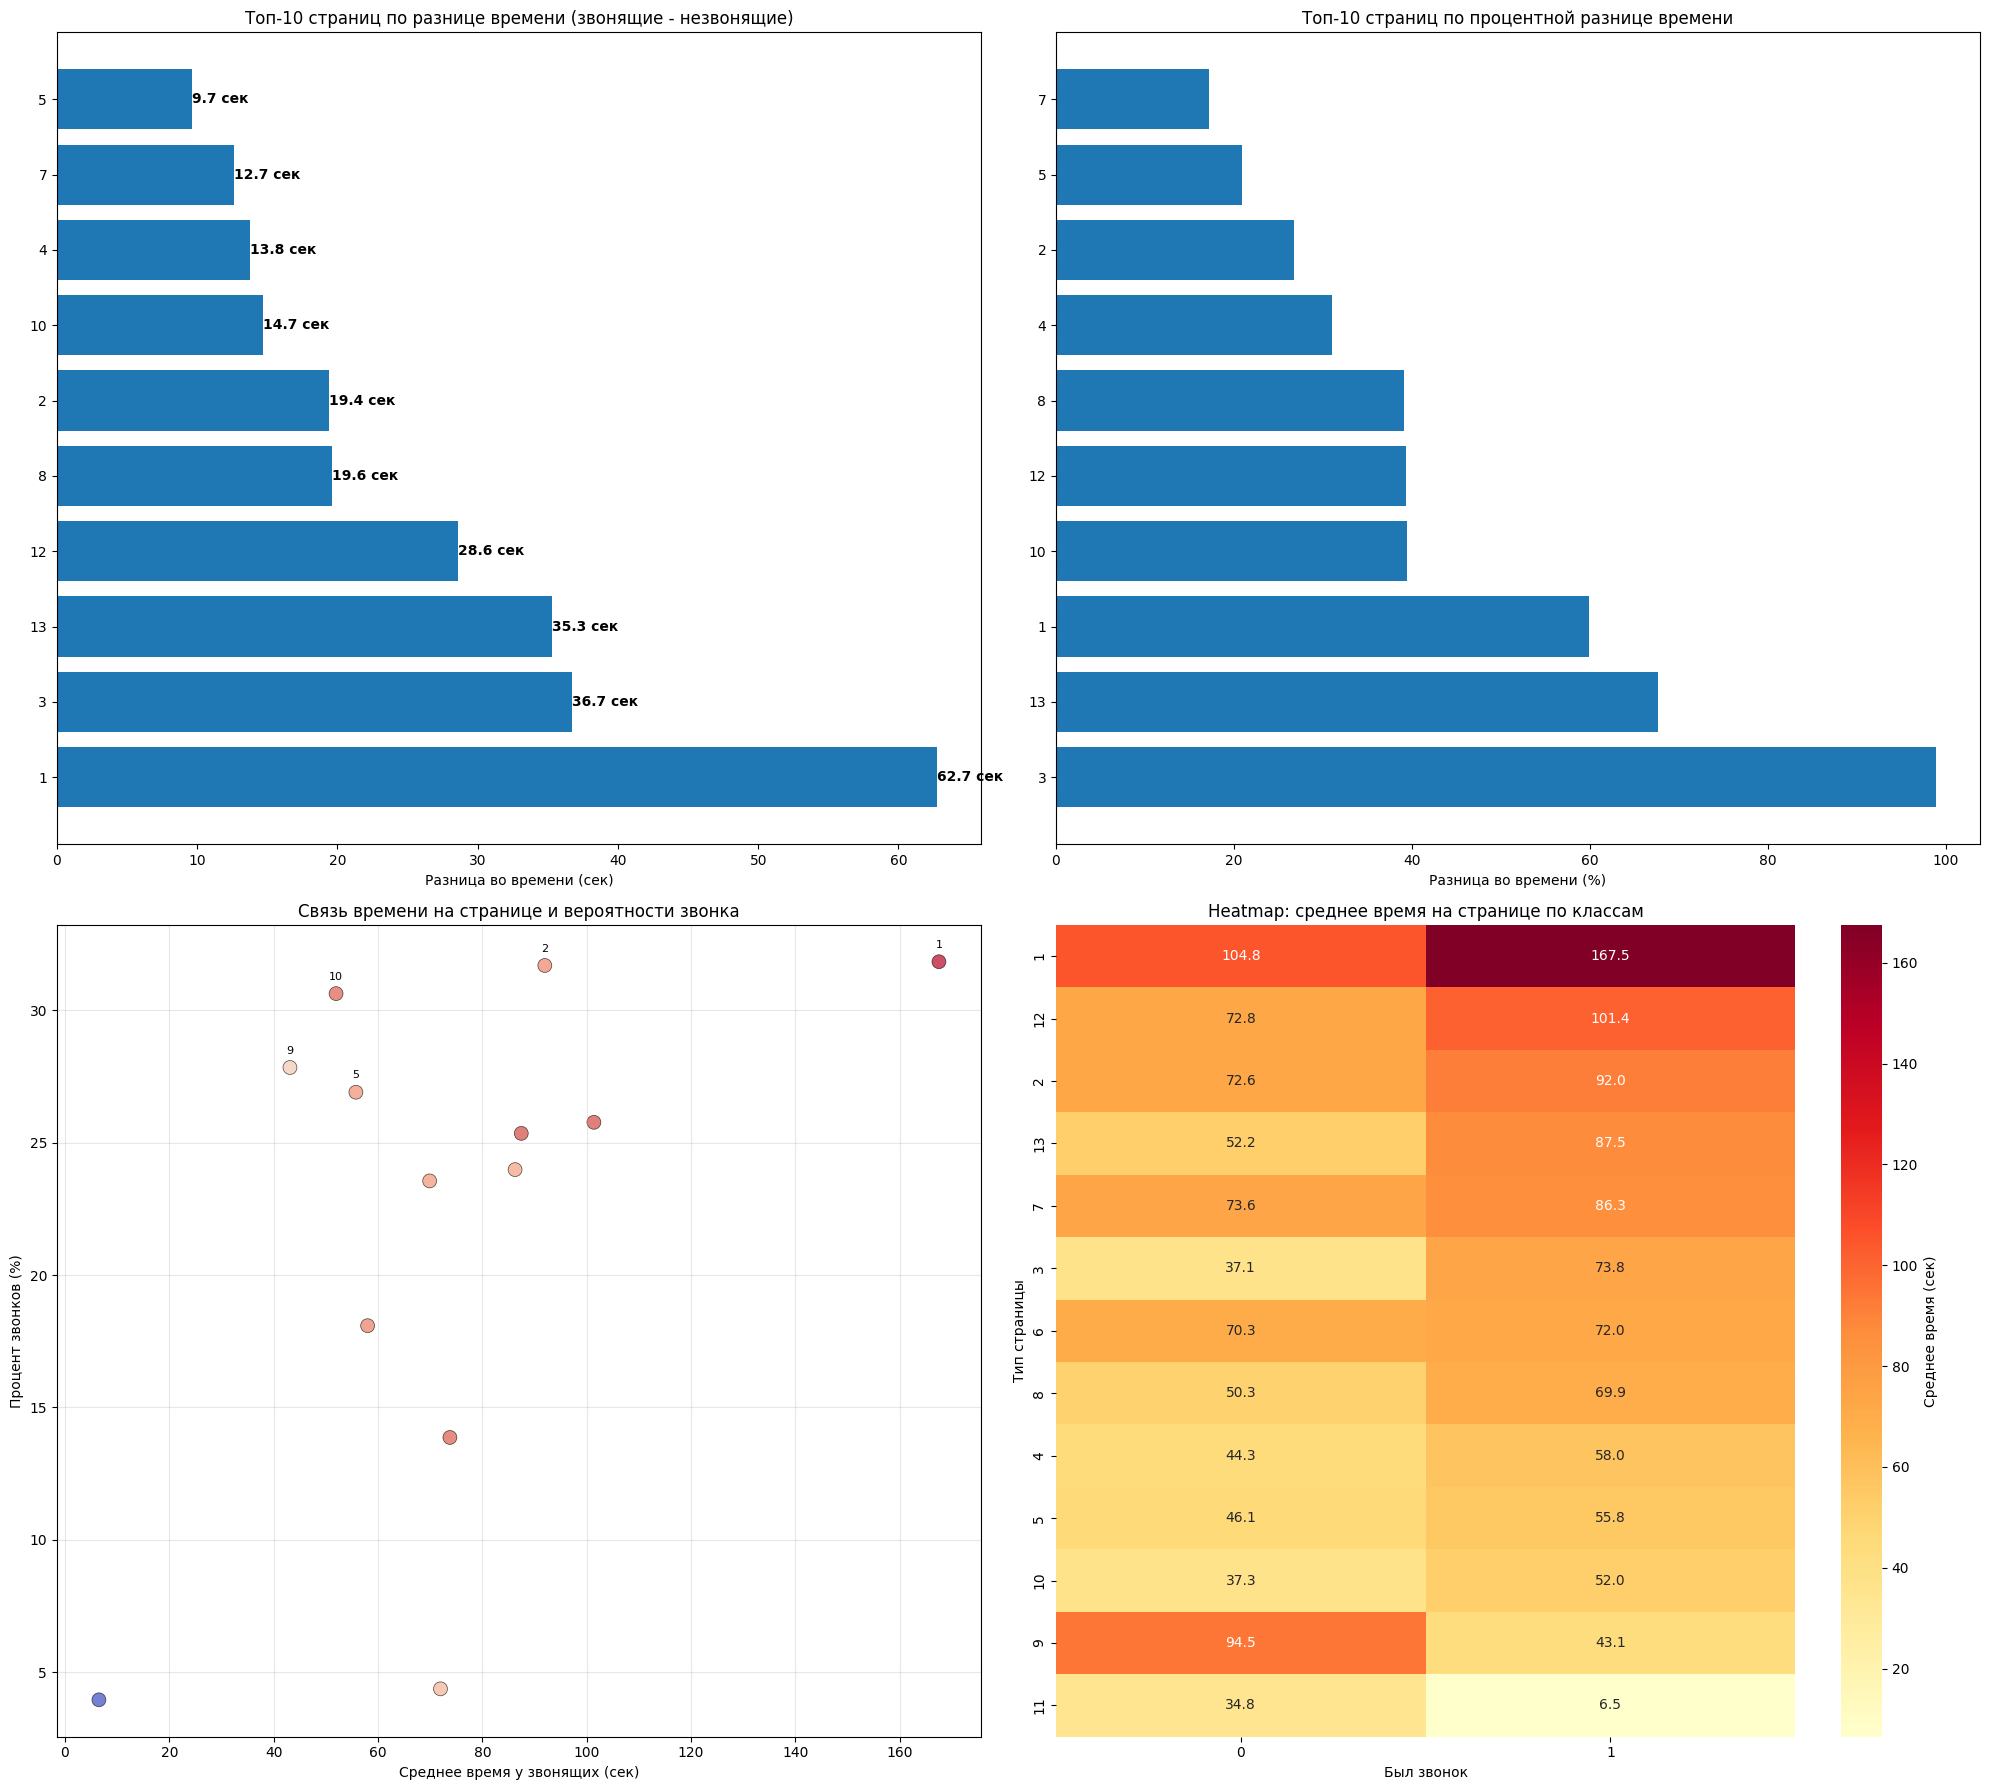

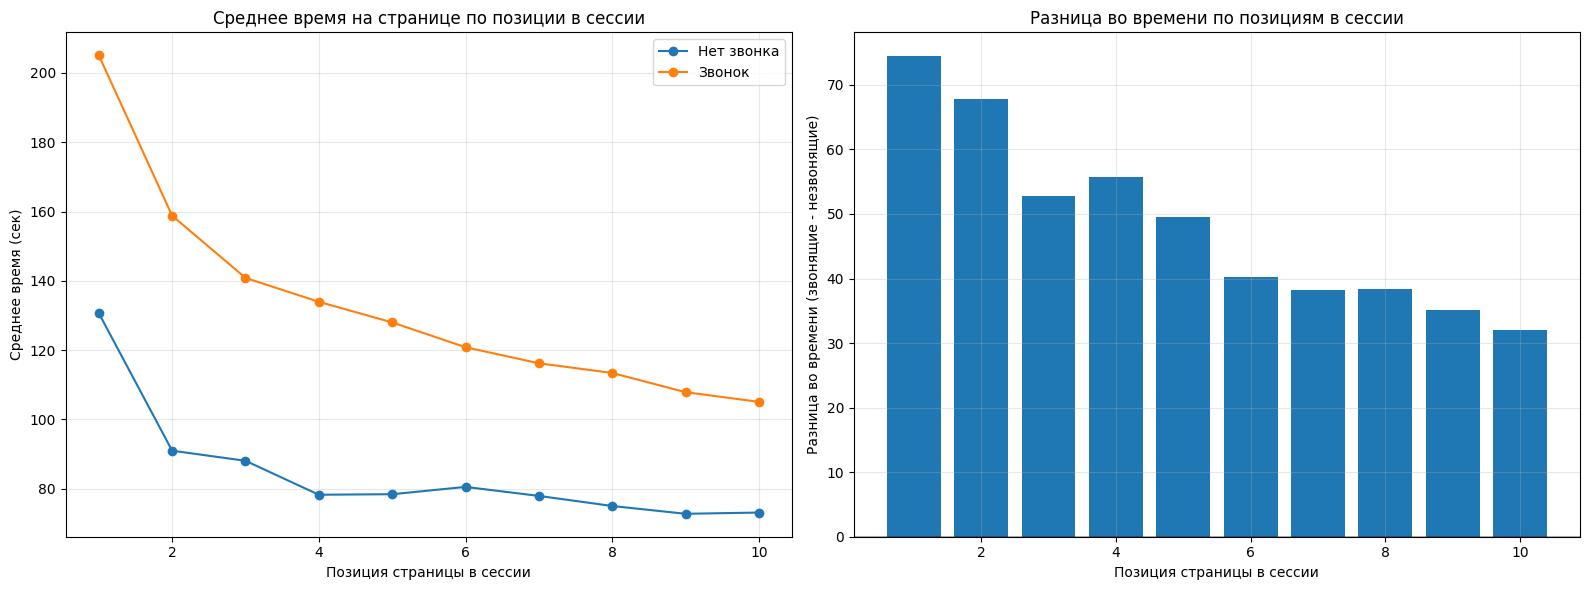

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_page_duration_correlation(webstat_df, train_df, page_types=None, top_n=10):
    merged_df = pd.merge(webstat_df,
                        train_df[['sessionkey_id', 'is_callcenter']].drop_duplicates(),
                        on='sessionkey_id',
                        how='inner')

    if page_types is not None:
        merged_df = merged_df[merged_df['page_type'].isin(page_types)]

    page_stats = merged_df.groupby(['page_type', 'is_callcenter']).agg({
        'pageview_duration_sec': ['mean', 'median', 'std', 'count', 'sum']
    }).round(2)

    page_stats.columns = ['mean_duration', 'median_duration', 'std_duration',
                         'visit_count', 'total_duration']
    page_stats = page_stats.reset_index()

    page_comparison = []

    for page in merged_df['page_type'].unique():
        page_data = merged_df[merged_df['page_type'] == page]

        if len(page_data['is_callcenter'].unique()) < 2:
            continue

        mean_duration_0 = page_data[page_data['is_callcenter'] == 0]['pageview_duration_sec'].mean()
        mean_duration_1 = page_data[page_data['is_callcenter'] == 1]['pageview_duration_sec'].mean()

        median_duration_0 = page_data[page_data['is_callcenter'] == 0]['pageview_duration_sec'].median()
        median_duration_1 = page_data[page_data['is_callcenter'] == 1]['pageview_duration_sec'].median()

        if len(page_data[page_data['is_callcenter'] == 0]) > 1 and len(page_data[page_data['is_callcenter'] == 1]) > 1:
            t_stat, p_value = stats.ttest_ind(
                page_data[page_data['is_callcenter'] == 0]['pageview_duration_sec'].dropna(),
                page_data[page_data['is_callcenter'] == 1]['pageview_duration_sec'].dropna(),
                equal_var=False
            )
        else:
            t_stat, p_value = np.nan, np.nan

        if not (pd.isna(mean_duration_0) or pd.isna(mean_duration_1) or
                pd.isna(page_data[page_data['is_callcenter'] == 0]['pageview_duration_sec'].std()) or
                pd.isna(page_data[page_data['is_callcenter'] == 1]['pageview_duration_sec'].std())):
            std_0 = page_data[page_data['is_callcenter'] == 0]['pageview_duration_sec'].std()
            std_1 = page_data[page_data['is_callcenter'] == 1]['pageview_duration_sec'].std()
            pooled_std = np.sqrt((std_0**2 + std_1**2) / 2)
            cohens_d = (mean_duration_1 - mean_duration_0) / pooled_std if pooled_std > 0 else 0
        else:
            cohens_d = np.nan

        page_comparison.append({
            'page_type': page,
            'mean_duration_0': mean_duration_0,
            'mean_duration_1': mean_duration_1,
            'mean_difference': mean_duration_1 - mean_duration_0,
            'mean_difference_percent': ((mean_duration_1 - mean_duration_0) / mean_duration_0 * 100
                                        if mean_duration_0 > 0 else np.nan),
            'median_duration_0': median_duration_0,
            'median_duration_1': median_duration_1,
            'median_difference': median_duration_1 - median_duration_0,
            'visit_count_0': len(page_data[page_data['is_callcenter'] == 0]),
            'visit_count_1': len(page_data[page_data['is_callcenter'] == 1]),
            'total_visits': len(page_data),
            'call_rate': len(page_data[page_data['is_callcenter'] == 1]) / len(page_data),
            't_statistic': t_stat,
            'p_value': p_value,
            'cohens_d': cohens_d,
            'significant': p_value < 0.05 if not pd.isna(p_value) else False
        })

    comparison_df = pd.DataFrame(page_comparison)

    fig, axes = plt.subplots(2, 2, figsize=(20, 18))

    top_diff = comparison_df.sort_values('mean_difference', ascending=False).head(top_n)
    axes[0, 0].barh(range(len(top_diff)), top_diff['mean_difference'].values)
    axes[0, 0].set_yticks(range(len(top_diff)))
    axes[0, 0].set_yticklabels(top_diff['page_type'])
    axes[0, 0].set_xlabel('Разница во времени (сек)')
    axes[0, 0].set_title(f'Топ-{top_n} страниц по разнице времени (звонящие - незвонящие)')
    axes[0, 0].axvline(x=0, color='black', linestyle='--', alpha=0.5)

    for i, (idx, row) in enumerate(top_diff.iterrows()):
        axes[0, 0].text(row['mean_difference'], i,
                       f'{row["mean_difference"]:.1f} сек',
                       ha='left' if row['mean_difference'] >= 0 else 'right',
                       va='center', fontweight='bold')

    top_percent_diff = comparison_df[comparison_df['mean_duration_0'] > 0].copy()
    top_percent_diff = top_percent_diff.sort_values('mean_difference_percent',
                                                   ascending=False).head(top_n)
    axes[0, 1].barh(range(len(top_percent_diff)), top_percent_diff['mean_difference_percent'].values)
    axes[0, 1].set_yticks(range(len(top_percent_diff)))
    axes[0, 1].set_yticklabels(top_percent_diff['page_type'])
    axes[0, 1].set_xlabel('Разница во времени (%)')
    axes[0, 1].set_title(f'Топ-{top_n} страниц по процентной разнице времени')
    axes[0, 1].axvline(x=0, color='black', linestyle='--', alpha=0.5)

    popular_pages = comparison_df.sort_values('total_visits', ascending=False).head(5)

    pivot_data = merged_df.groupby(['page_type', 'is_callcenter'])['pageview_duration_sec'].mean().unstack()
    pivot_data = pivot_data.sort_values(by=1, ascending=False).head(15)

    if not pivot_data.empty:
        sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='YlOrRd',
                   ax=axes[1, 1], cbar_kws={'label': 'Среднее время (сек)'})
        axes[1, 1].set_title('Heatmap: среднее время на странице по классам')
        axes[1, 1].set_xlabel('Был звонок')
        axes[1, 1].set_ylabel('Тип страницы')

    scatter_data = comparison_df.copy()
    axes[1, 0].scatter(scatter_data['mean_duration_1'], scatter_data['call_rate'] * 100,
                      c=scatter_data['cohens_d'], cmap='coolwarm', s=100, alpha=0.7,
                      edgecolors='black', linewidth=0.5)

    for idx, row in scatter_data.nlargest(5, 'call_rate').iterrows():
        axes[1, 0].annotate(row['page_type'],
                           (row['mean_duration_1'], row['call_rate'] * 100),
                           textcoords="offset points", xytext=(0,10),
                           ha='center', fontsize=8)

    axes[1, 0].set_xlabel('Среднее время у звонящих (сек)')
    axes[1, 0].set_ylabel('Процент звонков (%)')
    axes[1, 0].set_title('Связь времени на странице и вероятности звонка')
    axes[1, 0].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


analyze_page_duration_correlation(webstat_df, train_df)


def analyze_duration_by_sequence_position(webstat_df, train_df, max_position=10):
    merged_df = pd.merge(webstat_df,
                        train_df[['sessionkey_id', 'is_callcenter']].drop_duplicates(),
                        on='sessionkey_id',
                        how='inner')

    merged_df = merged_df[merged_df['pageview_number'] <= max_position]

    position_stats = merged_df.groupby(['pageview_number', 'is_callcenter']).agg({
        'pageview_duration_sec': ['mean', 'median', 'std', 'count']
    }).round(2)

    position_stats.columns = ['mean_duration', 'median_duration', 'std_duration', 'count']
    position_stats = position_stats.reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for call_status in [0, 1]:
        data = position_stats[position_stats['is_callcenter'] == call_status]
        axes[0].plot(data['pageview_number'], data['mean_duration'],
                    marker='o', label=f'{"Звонок" if call_status == 1 else "Нет звонка"}')

    axes[0].set_xlabel('Позиция страницы в сессии')
    axes[0].set_ylabel('Среднее время (сек)')
    axes[0].set_title('Среднее время на странице по позиции в сессии')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    pivot_data = position_stats.pivot(index='pageview_number',
                                     columns='is_callcenter',
                                     values='mean_duration')

    if 0 in pivot_data.columns and 1 in pivot_data.columns:
        pivot_data['difference'] = pivot_data[1] - pivot_data[0]
        axes[1].bar(pivot_data.index, pivot_data['difference'])
        axes[1].set_xlabel('Позиция страницы в сессии')
        axes[1].set_ylabel('Разница во времени (звонящие - незвонящие)')
        axes[1].set_title('Разница во времени по позициям в сессии')
        axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


analyze_duration_by_sequence_position(webstat_df, train_df, max_position=10)

в целом когда человек долго на странице это лучше, чем когда человек мало на странице, судя по получивлейся аналитике

умозаклюыения какого-то крутого не будет, главное- что время, проведенной на страницах и тип станицы роляет на целевой признак, поэтому можно просто напихать всяких признаков, связанных со временем)))

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
web = pd.read_csv('t1_webstat.csv')

print(train.shape, test.shape, web.shape)

(78446, 20) (26149, 19) (3334243, 10)


если я добавлял к каждой функции небольшую аннотацию, это не значит, что ее написал гпт, а значит, что я просто позаботился о проверящем

## **обучай и властвуй:**

In [ ]:
def build_enhanced_session_features(webstat_df):
    df = webstat_df.copy()

    df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')
    df['page_type'] = df['page_type'].fillna('unknown').astype(str)

    features_list = []

    for session_id, group in df.groupby('sessionkey_id'):
        features = {'sessionkey_id': session_id}

        durations = group['pageview_duration_sec'].fillna(0)
        features.update({
            'total_session_duration': durations.sum(),
            'avg_page_duration': durations.mean(),
            'std_page_duration': durations.std(),
            'max_page_duration': durations.max(),
            'min_page_duration': durations.min(),
            'pages_viewed': len(group)
        })

        page_nums = group['pageview_number']
        features.update({
            'max_page_number': page_nums.max(),
            'avg_page_position': page_nums.mean()
        })

        features['unique_page_types'] = group['page_type'].nunique()

        if not group['date_time'].isna().all():
            valid_times = group['date_time'].dropna()
            if len(valid_times) > 0:
                session_start = valid_times.min()
                session_end = valid_times.max()
                features['session_duration_time'] = (session_end - session_start).total_seconds()
                features['session_hour'] = session_start.hour
                features['is_weekend'] = 1 if session_start.weekday() >= 5 else 0

                hour = session_start.hour
                if hour < 6:
                    features['session_day_part'] = 0
                elif hour < 12:
                    features['session_day_part'] = 1
                elif hour < 18:
                    features['session_day_part'] = 2
                else:
                    features['session_day_part'] = 3
            else:
                features.update({
                    'session_duration_time': 0,
                    'session_hour': 12,
                    'is_weekend': 0,
                    'session_day_part': 2
                })

        page_durations = group.groupby('page_type')['pageview_duration_sec'].sum()
        for page_type, duration in page_durations.items():
            col_name = f"duration_{page_type.replace(' ', '_').replace('/', '_')}"
            features[col_name] = duration

        if len(group) > 1:
            group_sorted = group.sort_values('date_time')
            time_diffs = group_sorted['date_time'].diff().dt.total_seconds()
            valid_diffs = time_diffs.dropna()
            if len(valid_diffs) > 0:
                features.update({
                    'time_between_mean': valid_diffs.mean(),
                    'time_between_std': valid_diffs.std(),
                    'time_between_max': valid_diffs.max()
                })

        features_list.append(features)

    features_df = pd.DataFrame(features_list)

    features_df['pages_per_minute'] = features_df['pages_viewed'] / (
        features_df['total_session_duration'] / 60 + 1
    )

    features_df['time_ratio'] = features_df.get('total_session_duration', 0) / (
        features_df['session_duration_time'] + 1
    )

    return features_df

In [ ]:
def build_user_features(order_df, session_features):
    order_agg_list = []

    for session_id, group in order_df.groupby('sessionkey_id'):
        features = {'sessionkey_id': session_id}
        features['num_orders'] = group['order_id'].nunique()

        numeric_cols = ['price', 'goods_qty', 'rating_value', 'rating_count',
                        'description_length', 'pics_qty']

        for col in numeric_cols:
            col_data = pd.to_numeric(group[col], errors='coerce').fillna(0)
            features.update({
                f'{col}_sum': col_data.sum(),
                f'{col}_mean': col_data.mean(),
                f'{col}_std': col_data.std()
            })

        cat_cols = ['good_id', 'category_id', 'parent_id', 'root_id']

        for col in cat_cols:
            features[f'{col}_nunique'] = group[col].nunique()

        order_agg_list.append(features)

    order_agg_df = pd.DataFrame(order_agg_list)

    user_features = pd.merge(
        order_agg_df,
        session_features,
        on='sessionkey_id',
        how='left'
    )

    for col in user_features.columns.drop(["sessionkey_id"]):
        user_features[col] = (
            user_features[col].fillna(0)
            if user_features[col].dtype in ['float64', 'int64']
            else user_features[col].fillna('unknown')
        )

    user_features['price_per_page'] = user_features['price_sum'] / (user_features['pages_viewed'] + 1)
    user_features['browsing_intensity'] = user_features['pages_viewed'] / (user_features['total_session_duration'] + 1)
    user_features['unique_goods_per_page'] = user_features['good_id_nunique'] / (user_features['pages_viewed'] + 1)

    result = pd.merge(
        order_df,
        user_features,
        on="sessionkey_id",
        how="left"
    )

    return result

In [ ]:
def clean_dataframe(df):
    df_clean = df.copy()

    for col in df_clean.select_dtypes(include=[np.number]).columns:
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)

        if df_clean[col].notna().any():
            q99 = df_clean[col].quantile(0.99)
            df_clean[col] = df_clean[col].clip(upper=q99)

    for col in df_clean.columns:
        if col != 'sessionkey_id':
            if df_clean[col].dtype in ['float64', 'int64']:
                df_clean[col] = df_clean[col].fillna(0)
            elif df_clean[col].dtype == 'object':
                df_clean[col] = df_clean[col].fillna('unknown')

    return df_clean

In [ ]:
session_features = build_enhanced_session_features(web)
print(f"Session features shape: {session_features.shape}")

Session features shape: (328430, 32)


In [ ]:
train_features = build_user_features(train, session_features)
test_features = build_user_features(test, session_features)

print(f"Train features shape: {train_features.shape}")
print(f"Test features shape: {test_features.shape}")

Train features shape: (78446, 77)
Test features shape: (26149, 76)


In [ ]:
train_features_clean = clean_dataframe(train_features)
test_features_clean = clean_dataframe(test_features)

categorical_cols = []
for col in train_features_clean.columns:
    if col not in ['sessionkey_id', 'is_callcenter']:
        if train_features_clean[col].dtype == 'object':
            categorical_cols.append(col)

In [ ]:
label_encoders = {}
for col in categorical_cols:
    combined = pd.concat([
        train_features_clean[col].astype(str),
        test_features_clean[col].astype(str)
    ], axis=0)

    le = LabelEncodersesssesezsesssssssssssssssssesseeeesseessssssseseesesssssssssssesssssesesesessesessesesssesssesssesesesssseseseeseessesseessesssssssssssssssssssssssssssssssss()
    le.fit(combined)

    label_encoders[col] = le

    train_features_clean[col] = le.transform(train_features_clean[col].astype(str))
    test_features_clean[col] = le.transform(test_features_clean[col].astype(str))

In [ ]:
y = train_features_clean['is_callcenter'].astype(int)
X = train_features_clean.drop(columns=['is_callcenter', 'sessionkey_id'])

X_test = test_features_clean.drop(columns=['sessionkey_id'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_test shape: {X_test.shape}")

X shape: (78446, 75)
y shape: (78446,)
X_test shape: (26149, 75)


In [ ]:
# ну вдруг я где-то накосячил у меня будут различаться фичи)))))
common_cols = list(set(X.columns) & set(X_test.columns))
X = X[common_cols]
X_test = X_test[common_cols]

print(f"Common columns: {len(common_cols)}")

zero_var_cols = []
for col in X.columns:
    if X[col].std() == 0:
        zero_var_cols.append(col)

if zero_var_cols:
    X = X.drop(columns=zero_var_cols)
    X_test = X_test.drop(columns=zero_var_cols)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)


Common columns: 72


In [ ]:
params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.01,
    "num_leaves": 31,
    "max_depth": 7,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_scaled))
test_preds = np.zeros(len(X_test_scaled))
feature_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    print(f"\nFold {fold + 1}/{skf.n_splits}")

    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    dtrain = lgb.Dataset(X_train, y_train)
    dval = lgb.Dataset(X_val, y_val, reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=10000,
        valid_sets=[dtrain, dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=200, verbose=False),
            lgb.log_evaluation(500)
        ]
    )

    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(X_test_scaled) / skf.n_splits

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"  Fold {fold+1} AUC: {fold_auc:.4f}")

cv_auc = roc_auc_score(y, oof_preds)
print('='*50)
print(f"Cross-Validation ROC-AUC: {cv_auc:.4f}")
print('='*50)



Fold 1/5
[500]	training's auc: 0.927617	valid_1's auc: 0.92006
[1000]	training's auc: 0.937806	valid_1's auc: 0.92314
[1500]	training's auc: 0.945073	valid_1's auc: 0.92428
[2000]	training's auc: 0.950953	valid_1's auc: 0.925157
[2500]	training's auc: 0.955917	valid_1's auc: 0.925764
[3000]	training's auc: 0.960304	valid_1's auc: 0.926112
[3500]	training's auc: 0.964128	valid_1's auc: 0.926264
[4000]	training's auc: 0.967575	valid_1's auc: 0.926364
  Fold 1 AUC: 0.9264

Fold 2/5
[500]	training's auc: 0.927685	valid_1's auc: 0.920463
[1000]	training's auc: 0.937973	valid_1's auc: 0.923697
[1500]	training's auc: 0.945037	valid_1's auc: 0.925004
[2000]	training's auc: 0.951022	valid_1's auc: 0.926004
[2500]	training's auc: 0.956021	valid_1's auc: 0.926643
[3000]	training's auc: 0.960396	valid_1's auc: 0.927008
[3500]	training's auc: 0.964297	valid_1's auc: 0.927315
[4000]	training's auc: 0.967858	valid_1's auc: 0.927589
[4500]	training's auc: 0.971007	valid_1's auc: 0.927731
[5000]	train

In [ ]:
submission = pd.DataFrame({
    'id': test['Unnamed: 0'],
    'is_callcenter': test_preds
})

submission_file = "submission_final.csv"
submission.to_csv(submission_file, index=False)